# Experiment 3 — Controlled Directional Perturbation via PCA Latent Shift

Assess sensitivity/uncertainty of DiT by measuring how much the **final image** changes when a mid-trajectory latent is shifted along an empirically-estimated **PCA direction of the latent space**, then denoised to completion with a fixed denoising-noise seed.

**Protocol** (repeated independently for every class below)
1. Generate one reference reverse trajectory from a fixed seed (`traj_seed`); save latents every 50 reverse steps (checkpoints).
2. At each checkpoint, empirically estimate a local PCA basis of the latent space by generating an ensemble of `K_pca` independently-seeded full trajectories (same class) and collecting their latents at that checkpoint.
3. For each of the top PCA components, shift the reference latent by $\alpha \in \{-3,-1,+1,+3\}$ standard deviations ($\sqrt{\text{eigenvalue}}$) along that component — a controlled, *directional* (not random) corruption, at the *same* timestep (no backward noise jump).
4. Continue denoising from that checkpoint using a **shared / fixed denoising-noise seed** across every (component, $\alpha$) condition, so any downstream image difference is attributable only to the directional latent shift.
5. Compare each perturbed final against an unperturbed **control final** ($\alpha=0$, same shared denoise seed, same checkpoint) via CLIP / DINOv2 embedding distance, LPIPS, and latent MSE.

**Class selection.** We run this protocol over the **KID difficulty tiers** from `results/ensemble_K50_fid/kid_difficulty_tiers.png` — the 15 **hardest** (highest KID), 15 **medium**, and 15 **easiest** (lowest KID) classes — to test whether PCA-directional sensitivity tracks per-class generation difficulty. Tier-aggregated plots cover all 45 classes; detailed image grids / diff maps are shown for one *spotlight* (median-KID) class per tier.


# 1. Setup


In [1]:
%cd ../


/home/sepuhopar/dev/SMILES-Project-27-Uncertainty-in-Diffusion


In [2]:
#!git clone https://github.com/facebookresearch/DiT.git
import DiT, os
os.chdir("DiT")

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from tqdm.auto import tqdm
from torchvision.utils import make_grid, save_image

from diffusion import create_diffusion
from diffusers.models import AutoencoderKL
from download import find_model
from models import DiT_XL_2

torch.set_grad_enabled(False)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device={device}")
if device == "cpu":
    print("GPU not found. Using CPU instead.")


Multiple distributions found for package optimum. Picked distribution: optimum
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


device=cuda


# 2. Load DiT-XL/2


In [3]:
image_size = 256  #@param [256, 512]
vae_model = "stabilityai/sd-vae-ft-ema"  #@param ["stabilityai/sd-vae-ft-mse", "stabilityai/sd-vae-ft-ema"]
latent_size = int(image_size) // 8

model = DiT_XL_2(input_size=latent_size).to(device)
state_dict = find_model(f"DiT-XL-2-{image_size}x{image_size}.pt")
model.load_state_dict(state_dict)
model.eval()
vae = AutoencoderKL.from_pretrained(vae_model).to(device)
print("Model + VAE ready.")


/home/sepuhopar/miniconda3/envs/ldm/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Model + VAE ready.


# 3. Config — KID difficulty tiers

Classes are taken from the same ranking used to build `results/ensemble_K50_fid/kid_difficulty_tiers.png`: 15 hardest / 15 medium / 15 easiest by per-class KID.


In [4]:
# ---- Sampling ----
cfg_scale = 4.0  #@param {type:"slider", min:1, max:10, step:0.1}
num_sampling_steps = 250  #@param {type:"slider", min:10, max:1000, step:1}
traj_seed = 0  #@param {type:"integer"}  # fixed start for each class's reference trajectory

# Save a latent checkpoint every N reverse steps (0 < checkpoint < T).
every_n_steps = 50  #@param {type:"integer"}

# ---- PCA basis (built per-checkpoint from an ensemble of extra seeded trajectories) ----
K_pca = 32  #@param {type:"integer"}              # #extra trajectories used to estimate PCA per checkpoint
pca_components = (0, 1, 2)  #@param {type:"raw"}  # which PCs to test (0 = top/dominant component)
alphas = (-3.0, -1.0, 1.0, 3.0)  #@param {type:"raw"}  # shift magnitude, in std (sqrt eigenvalue) units

# ---- Seeds ----
pca_seed_base = 5000  #@param {type:"integer"}        # seeds for the K_pca PCA-fitting trajectories
shared_denoise_seed = 12345  #@param {type:"integer"}  # fixed reverse step-noise shared by control + every perturbation

# ---- KID difficulty tiers (same split as kid_difficulty_tiers.png) ----
KID_JSON = Path("../results/ensemble_K50_fid/kid_per_class.json")
IMAGENET_IDX = Path("../results/ensemble_K50_fid/imagenet_class_index.json")

with open(KID_JSON) as f:
    kid_per_class = {int(k): v for k, v in json.load(f).items()}
with open(IMAGENET_IDX) as f:
    _idx = json.load(f)
class_names = {i: _idx[str(i)][1] for i in range(len(_idx))}

kid_ranked = sorted(kid_per_class.keys(), key=lambda c: kid_per_class[c]["kid"], reverse=True)
n_ranked = len(kid_ranked)
TIER_SIZE = min(15, n_ranked // 3 if n_ranked >= 3 else n_ranked)

hardest_classes = kid_ranked[:TIER_SIZE]
easiest_classes = kid_ranked[-TIER_SIZE:] if TIER_SIZE > 0 else []
mid_start = max(0, n_ranked // 2 - TIER_SIZE // 2)
medium_classes = kid_ranked[mid_start: mid_start + TIER_SIZE]

tiers = {
    "hardest": hardest_classes,
    "medium": medium_classes,
    "easiest": easiest_classes,
}
tier_colors = {
    "hardest": "crimson",
    "medium": "goldenrod",
    "easiest": "seagreen",
}

# One spotlight class per tier (median-KID within the tier) for detailed visuals
spotlight_classes = {name: cls_list[len(cls_list) // 2] for name, cls_list in tiers.items()}

# Checkpoints shown in spotlight image grids / diff maps
spotlight_show_steps = (100, 150)  #@param {type:"raw"}

class_labels = hardest_classes + medium_classes + easiest_classes
class_to_tier = {}
for name, cls_list in tiers.items():
    for c in cls_list:
        class_to_tier[c] = name

RESULTS_DIR = Path("../results/exp3_pca_perturbation")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

diffusion = create_diffusion(str(num_sampling_steps))
shape = (1, 4, latent_size, latent_size)
T = diffusion.num_timesteps
assert T == num_sampling_steps, (T, num_sampling_steps)

checkpoint_steps = tuple(range(every_n_steps, T, every_n_steps))
assert all(0 < s < T for s in checkpoint_steps), "checkpoints must allow at least one more denoising step"

spotlight_show_steps = tuple(int(s) for s in spotlight_show_steps)
assert all(s in checkpoint_steps for s in spotlight_show_steps), (
    f"spotlight_show_steps={spotlight_show_steps} must be subset of checkpoint_steps={checkpoint_steps}"
)

print(f"steps={T}, cfg={cfg_scale}, checkpoints={checkpoint_steps}")
print(f"K_pca={K_pca}, pca_components={pca_components}, alphas={alphas}")
print(f"shared_denoise_seed={shared_denoise_seed}")
print(f"\nTIER_SIZE={TIER_SIZE} | total classes to run = {len(class_labels)}")
for name, cls_list in tiers.items():
    print(f"\n=== {name} ({len(cls_list)}) | spotlight={spotlight_classes[name]} ({class_names.get(spotlight_classes[name], '?')}) ===")
    for c in cls_list:
        print(f"  class {c:>4}  KID={kid_per_class[c]['kid']:.4f}  {class_names.get(c, '?')}")


steps=250, cfg=4.0, checkpoints=(50, 100, 150, 200)
K_pca=32, pca_components=(0, 1, 2), alphas=(-3.0, -1.0, 1.0, 3.0)
shared_denoise_seed=12345

TIER_SIZE=15 | total classes to run = 45

=== hardest (15) | spotlight=61 (boa_constrictor) ===
  class   63  KID=0.0876  Indian_cobra
  class   38  KID=0.0845  banded_gecko
  class   34  KID=0.0719  leatherback_turtle
  class   47  KID=0.0660  African_chameleon
  class   51  KID=0.0614  triceratops
  class   33  KID=0.0612  loggerhead
  class  979  KID=0.0610  valley
  class   61  KID=0.0599  boa_constrictor
  class   21  KID=0.0569  kite
  class   44  KID=0.0559  alligator_lizard
  class   36  KID=0.0538  terrapin
  class   35  KID=0.0538  mud_turtle
  class   67  KID=0.0535  diamondback
  class   29  KID=0.0528  axolotl
  class   65  KID=0.0525  sea_snake

=== medium (15) | spotlight=360 (otter) ===
  class   10  KID=0.0315  brambling
  class    9  KID=0.0309  ostrich
  class   91  KID=0.0307  coucal
  class   71  KID=0.0302  scorpion
  cla

# 4. Diffusion helpers

Indexing convention:
- Reverse step index $s=0$: initial noise (input to the first reverse step).
- After $s$ reverse steps, latent `traj[s]` is the input for spaced timestep index $i = T-1-s$.
- The PCA perturbation shifts the latent *at the same reverse-step* $s$ (no time jump); only `denoise_from` is needed to resume.


In [5]:
def spaced_index_at_step(s):
    """Spaced diffusion index used as model-t when the latent is traj[s] (s < T)."""
    return T - 1 - s


def decode_latents(latents):
    return vae.decode(latents / 0.18215).sample


def save_uint8_image(tensor_chw, path):
    x = torch.clamp(127.5 * tensor_chw + 128.0, 0, 255)
    x = x.permute(1, 2, 0).to("cpu", dtype=torch.uint8).numpy()
    Image.fromarray(x).save(path)


def p_sample_with_noise(diffusion, model_fn, x, t, step_noise, model_kwargs):
    """Like diffusion.p_sample, but uses provided step_noise instead of randn."""
    out = diffusion.p_mean_variance(
        model_fn, x, t, clip_denoised=False, model_kwargs=model_kwargs
    )
    nonzero_mask = (t != 0).float().view(-1, *([1] * (len(x.shape) - 1)))
    sample = out["mean"] + nonzero_mask * torch.exp(0.5 * out["log_variance"]) * step_noise
    return {"sample": sample, "pred_xstart": out["pred_xstart"]}


def precompute_step_noise(noise_seed, start_step=0):
    """Per reverse-step eps for CFG batch (2, C, H, W), indexed by reverse step_i."""
    g = torch.Generator(device=device)
    g.manual_seed(int(noise_seed))
    noises = []
    for _ in range(T):
        noises.append(torch.randn(2, 4, latent_size, latent_size, generator=g, device=device))
    return noises[start_step:]


def cfg_kwargs(class_label):
    y = torch.tensor([class_label, 1000], device=device)
    return dict(y=y, cfg_scale=cfg_scale)


def generate_trajectory(class_label, seed, save_steps):
    """Run one full reverse path; return dict step -> latent (1,C,H,W) on CPU.

    traj[0] = initial noise; traj[T] = final latent.
    """
    save_set = set(save_steps) | {0, T}
    torch.manual_seed(seed)
    z = torch.randn(*shape, device=device)
    img = torch.cat([z, z], dim=0)
    model_kwargs = cfg_kwargs(class_label)

    traj = {}
    if 0 in save_set:
        traj[0] = img[:1].detach().cpu()

    indices = list(range(T))[::-1]
    for step_i, i in enumerate(tqdm(indices, desc="trajectory", leave=False)):
        t = torch.tensor([i, i], device=device)
        out = diffusion.p_sample(
            model.forward_with_cfg,
            img,
            t,
            clip_denoised=False,
            model_kwargs=model_kwargs,
        )
        img = out["sample"]
        s = step_i + 1
        if s in save_set:
            traj[s] = img[:1].detach().cpu()

    return traj


def denoise_from(x_start, start_step, class_label, step_noises):
    """Continue reverse diffusion from reverse-step start_step to the end.

    step_noises[k] is used at reverse step start_step + k (CFG-shaped).
    Returns final latent (1,C,H,W) on CPU.
    """
    img = x_start.to(device)
    img = torch.cat([img, img], dim=0)
    model_kwargs = cfg_kwargs(class_label)
    indices = list(range(T))[::-1]

    for k, step_i in enumerate(range(start_step, T)):
        i = indices[step_i]
        t = torch.tensor([i, i], device=device)
        out = p_sample_with_noise(
            diffusion,
            model.forward_with_cfg,
            img,
            t,
            step_noises[k],
            model_kwargs,
        )
        img = out["sample"]

    return img[:1].detach().cpu()


print("Diffusion helpers ready.")


Diffusion helpers ready.


# 5. Feature / distance metric helpers (CLIP, DINOv2, LPIPS, latent MSE)

Unlike Experiment 1 (ensemble spread across seeds), each PCA-perturbation condition here is a single deterministic trajectory. We therefore report **pairwise distance** between each perturbed final and the unperturbed **control final** at the same checkpoint (same shared denoise seed), rather than ensemble variance.


In [6]:
import open_clip
import lpips
from transformers import AutoImageProcessor, AutoModel


# ---- CLIP (OpenCLIP ViT-B/32) ----
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="openai"
)
clip_model = clip_model.to(device).eval()

# ---- DINOv2 ----
dino_name = "facebook/dinov2-small"
dino_processor = AutoImageProcessor.from_pretrained(dino_name)
dino_model = AutoModel.from_pretrained(dino_name).to(device).eval()

# ---- LPIPS ----
lpips_fn = lpips.LPIPS(net="alex").to(device).eval()


def _images_to_pil_list(imgs_bchw):
    """imgs in [-1,1] -> list of PIL RGB."""
    x = torch.clamp(imgs_bchw * 0.5 + 0.5, 0, 1)
    out = []
    for i in range(x.shape[0]):
        arr = (x[i].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
        out.append(Image.fromarray(arr))
    return out


@torch.no_grad()
def embed_clip(imgs_bchw):
    pils = _images_to_pil_list(imgs_bchw)
    tensors = torch.stack([clip_preprocess(p) for p in pils]).to(device)
    feats = clip_model.encode_image(tensors)
    return F.normalize(feats.float(), dim=-1).cpu()


@torch.no_grad()
def embed_dino(imgs_bchw):
    pils = _images_to_pil_list(imgs_bchw)
    inputs = dino_processor(images=pils, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    out = dino_model(**inputs)
    feats = out.last_hidden_state[:, 0]
    return F.normalize(feats.float(), dim=-1).cpu()


@torch.no_grad()
def pairwise_metrics(latent_a, latent_b):
    """Compare two single final latents (1,C,H,W) CPU (e.g. perturbed vs control).

    Returns (metrics_dict, img_a, img_b) with images decoded to (C,H,W) in [-1,1] on CPU.
    """
    imgs = decode_latents(torch.cat([latent_a, latent_b], dim=0).to(device)).cpu()
    img_a, img_b = imgs[0:1], imgs[1:2]

    clip_f = embed_clip(imgs)
    dino_f = embed_dino(imgs)
    clip_cos_dist = float(1.0 - (clip_f[0] @ clip_f[1]))
    dino_cos_dist = float(1.0 - (dino_f[0] @ dino_f[1]))
    lpips_d = float(lpips_fn(img_a.to(device), img_b.to(device)).item())
    latent_mse = float(F.mse_loss(latent_a.reshape(-1), latent_b.reshape(-1)).item())
    pixel_mse = float(F.mse_loss(img_a, img_b).item())

    metrics = {
        "clip_cos_dist": clip_cos_dist,
        "dino_cos_dist": dino_cos_dist,
        "lpips": lpips_d,
        "latent_mse": latent_mse,
        "pixel_mse": pixel_mse,
    }
    return metrics, img_a[0], img_b[0]


print("Metric helpers ready (CLIP / DINOv2 / LPIPS, pairwise-vs-control).")


/home/sepuhopar/miniconda3/envs/ldm/lib/python3.11/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/sepuhopar/miniconda3/envs/ldm/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/sepuhopar/miniconda3/envs/ldm/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/sepuhopar/miniconda3/envs/ldm/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth
Metric helpers ready (CLIP / DINOv2 / LPIPS, pairwise-vs-control).


# 6. Per-class experiment pipeline

Helpers that run the full protocol for one ImageNet class and write results under `results/exp3_pca_perturbation/class_XXXX/`. Existing caches (`traj_*.pt`, `pca_ensemble_*.pt`, `metrics_*.json`) are reused so re-runs skip finished work.


In [ ]:
def fit_pca(latents_kchw, n_components):
    """Fit PCA on an ensemble of latents via SVD of the centered data matrix."""
    K = latents_kchw.shape[0]
    flat = latents_kchw.reshape(K, -1).double()
    mean = flat.mean(dim=0)
    centered = flat - mean
    _, S, Vh = torch.linalg.svd(centered, full_matrices=False)
    eigvals = (S ** 2) / (K - 1)
    total_var = eigvals.sum()

    n = min(n_components, Vh.shape[0])
    components = Vh[:n]
    std = torch.sqrt(eigvals[:n].clamp(min=0))
    explained_ratio = (eigvals[:n] / total_var).float()

    return {
        "mean": mean.float().reshape(latents_kchw.shape[1:]),
        "components": components.float().reshape(n, *latents_kchw.shape[1:]),
        "std": std.float(),
        "explained_variance_ratio": explained_ratio,
    }


def pca_perturb(x_s, basis, component_idx, alpha):
    """Shift latent x_s (1,C,H,W CPU) by alpha std-units along PCA component."""
    v = basis["components"][component_idx]
    std = basis["std"][component_idx].item()
    shift = (alpha * std) * v
    return (x_s.squeeze(0) + shift).unsqueeze(0)


def _log(msg):
    print(msg, flush=True)


def _save_spotlight_pngs(class_label, samples_dir, show_steps, pca_basis, control_finals, exp3_results):
    """Write grid + diffmap PNGs for the requested checkpoint steps only."""
    for s in show_steps:
        with torch.no_grad():
            control_img = decode_latents(control_finals[s].to(device))[0].cpu()
        for c in pca_components:
            imgs = [control_img] + [exp3_results[(s, c, a)]["img"] for a in alphas]
            panel = torch.stack(imgs, dim=0)
            grid = make_grid(panel, nrow=len(panel), normalize=True, value_range=(-1, 1))
            plt.figure(figsize=(3 * len(panel), 3.2))
            plt.imshow(grid.permute(1, 2, 0).numpy())
            plt.axis("off")
            plt.title(f"class {class_label} | s={s}, PC{c + 1}")
            plt.savefig(samples_dir / f"grid_s{s}_pc{c + 1}.png", dpi=140, bbox_inches="tight")
            plt.close()

            fig, axs = plt.subplots(1, len(alphas) + 1, figsize=(3.2 * (len(alphas) + 1), 3.4))
            axs[0].imshow((control_img.permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1))
            axs[0].set_title("control")
            axs[0].axis("off")
            im = None
            for ax, a in zip(axs[1:], alphas):
                pert_img = exp3_results[(s, c, a)]["img"]
                diff = (pert_img - control_img).abs().mean(dim=0).numpy()
                im = ax.imshow(diff, cmap="magma")
                ax.set_title(f"|d| a={a:+.1f}")
                ax.axis("off")
            fig.colorbar(im, ax=axs[-1], fraction=0.046, pad=0.04)
            fig.suptitle(f"|pert-ctrl| | class {class_label} s={s} PC{c + 1}")
            plt.tight_layout()
            fig.savefig(samples_dir / f"diffmap_s{s}_pc{c + 1}.png", dpi=140, bbox_inches="tight")
            plt.close(fig)


def save_spotlight_visuals(class_label, show_steps=None):
    """Generate grid/diffmap PNGs at selected checkpoints ONLY.

    Uses cached traj + PCA ensemble (no full-class re-run). Metrics JSON is untouched.
    Typical cost: len(show_steps) checkpoints x (3 PCs x 4 alphas) short denoises.
    """
    if show_steps is None:
        show_steps = spotlight_show_steps
    show_steps = tuple(int(s) for s in show_steps)

    samples_dir = RESULTS_DIR / f"class_{class_label:04d}"
    metrics_path = samples_dir / "metrics_pca_perturbation.json"
    if not metrics_path.exists():
        raise FileNotFoundError(
            f"No metrics for class {class_label}. Run §7 first for this class."
        )

    grids_ok = all(
        (samples_dir / f"grid_s{s}_pc{c + 1}.png").exists()
        for s in show_steps
        for c in pca_components
    )
    if grids_ok:
        _log(f"  [{class_label}] spotlight PNGs already exist for s={show_steps}")
        return

    traj_path = samples_dir / f"traj_seed{traj_seed}.pt"
    pca_ensemble_path = samples_dir / f"pca_ensemble_K{K_pca}.pt"
    if not traj_path.exists() or not pca_ensemble_path.exists():
        raise FileNotFoundError(
            f"Missing traj or PCA ensemble cache for class {class_label}."
        )

    _log(f"  [{class_label}] rendering spotlight visuals at s={show_steps} (metrics already saved)")

    payload = torch.load(traj_path, map_location="cpu", weights_only=False)
    traj = {int(k): v for k, v in payload["traj"].items()}
    payload = torch.load(pca_ensemble_path, map_location="cpu", weights_only=False)
    pca_latents = {int(k): v for k, v in payload["pca_latents"].items()}

    n_components_needed = max(pca_components) + 1
    pca_basis = {s: fit_pca(pca_latents[s], n_components_needed) for s in checkpoint_steps}

    control_finals = {}
    shared_noises_by_step = {}
    for s in show_steps:
        shared_noises = precompute_step_noise(shared_denoise_seed, start_step=s)
        shared_noises_by_step[s] = shared_noises
        control_finals[s] = denoise_from(traj[s], s, class_label, shared_noises)

    exp3_results = {}
    n_jobs = len(show_steps) * len(pca_components) * len(alphas)
    pbar = tqdm(total=n_jobs, desc=f"vis class {class_label}", leave=True)
    for s in show_steps:
        x_s = traj[s]
        basis = pca_basis[s]
        shared_noises = shared_noises_by_step[s]
        control_final = control_finals[s]
        for c in pca_components:
            for alpha in alphas:
                x_pert = pca_perturb(x_s, basis, c, alpha)
                final = denoise_from(x_pert, s, class_label, shared_noises)
                metrics, img_pert, _ = pairwise_metrics(final, control_final)
                exp3_results[(s, c, alpha)] = {"metrics": metrics, "img": img_pert}
                pbar.update(1)
    pbar.close()

    _save_spotlight_pngs(class_label, samples_dir, show_steps, pca_basis, control_finals, exp3_results)
    _log(f"  [{class_label}] saved spotlight PNGs for s={show_steps}")


def run_class_experiment(class_label):
    """Full Exp3 protocol for one class. Returns metrics dict.

    If metrics_pca_perturbation.json exists, returns it immediately (no GPU re-run).
    """
    samples_dir = RESULTS_DIR / f"class_{class_label:04d}"
    samples_dir.mkdir(parents=True, exist_ok=True)
    metrics_path = samples_dir / "metrics_pca_perturbation.json"

    if metrics_path.exists():
        with open(metrics_path) as f:
            cached = json.load(f)
        _log(f"  [{class_label}] SKIP (cached metrics)")
        return cached

    # ---- reference trajectory ----
    traj_path = samples_dir / f"traj_seed{traj_seed}.pt"
    if traj_path.exists():
        payload = torch.load(traj_path, map_location="cpu", weights_only=False)
        traj = {int(k): v for k, v in payload["traj"].items()}
        _log(f"  [{class_label}] loaded traj cache")
    else:
        _log(f"  [{class_label}] generating reference trajectory (250 steps)...")
        traj = generate_trajectory(class_label, traj_seed, save_steps=list(checkpoint_steps))
        torch.save(
            {
                "traj": traj,
                "class_label": class_label,
                "traj_seed": traj_seed,
                "num_sampling_steps": T,
                "cfg_scale": cfg_scale,
            },
            traj_path,
        )
        _log(f"  [{class_label}] saved traj")

    ref_final = traj[T]
    with torch.no_grad():
        ref_img = decode_latents(ref_final.to(device))[0].cpu()
    save_uint8_image(ref_img, samples_dir / "reference_final.png")

    # ---- PCA ensemble ----
    pca_ensemble_path = samples_dir / f"pca_ensemble_K{K_pca}.pt"
    if pca_ensemble_path.exists():
        payload = torch.load(pca_ensemble_path, map_location="cpu", weights_only=False)
        pca_latents = {int(k): v for k, v in payload["pca_latents"].items()}
        _log(f"  [{class_label}] loaded PCA ensemble cache (K={K_pca})")
    else:
        _log(f"  [{class_label}] building PCA ensemble: {K_pca} trajectories (slow)...")
        pca_seeds = [pca_seed_base + k for k in range(K_pca)]
        per_seed_traj = []
        for seed in tqdm(pca_seeds, desc=f"PCA ens class {class_label}", leave=True):
            per_seed_traj.append(
                generate_trajectory(class_label, seed, save_steps=list(checkpoint_steps))
            )
        pca_latents = {
            s: torch.cat([t[s] for t in per_seed_traj], dim=0) for s in checkpoint_steps
        }
        torch.save(
            {
                "pca_latents": pca_latents,
                "K_pca": K_pca,
                "pca_seed_base": pca_seed_base,
                "class_label": class_label,
                "checkpoint_steps": list(checkpoint_steps),
            },
            pca_ensemble_path,
        )
        _log(f"  [{class_label}] saved PCA ensemble")

    n_components_needed = max(pca_components) + 1
    pca_basis = {s: fit_pca(pca_latents[s], n_components_needed) for s in checkpoint_steps}
    torch.save(pca_basis, samples_dir / f"pca_basis_K{K_pca}.pt")
    _log(f"  [{class_label}] fitted PCA basis")

    control_finals = {}
    shared_noises_by_step = {}
    _log(f"  [{class_label}] computing control finals at {len(checkpoint_steps)} checkpoints...")
    for s in tqdm(checkpoint_steps, desc=f"control class {class_label}", leave=True):
        shared_noises = precompute_step_noise(shared_denoise_seed, start_step=s)
        shared_noises_by_step[s] = shared_noises
        control_finals[s] = denoise_from(traj[s], s, class_label, shared_noises)

    n_jobs = len(checkpoint_steps) * len(pca_components) * len(alphas)
    _log(f"  [{class_label}] PCA perturbation sweep: {n_jobs} jobs...")
    exp3_results = {}
    pbar = tqdm(total=n_jobs, desc=f"pert class {class_label}", leave=True)
    for s in checkpoint_steps:
        x_s = traj[s]
        basis = pca_basis[s]
        shared_noises = shared_noises_by_step[s]
        control_final = control_finals[s]
        for c in pca_components:
            for alpha in alphas:
                x_pert = pca_perturb(x_s, basis, c, alpha)
                final = denoise_from(x_pert, s, class_label, shared_noises)
                metrics, img_pert, _ = pairwise_metrics(final, control_final)
                exp3_results[(s, c, alpha)] = {"metrics": metrics, "img": img_pert, "latent": final}
                pbar.update(1)
    pbar.close()

    metrics_out = {
        "config": {
            "class_label": class_label,
            "tier": class_to_tier.get(class_label),
            "kid": kid_per_class.get(class_label, {}).get("kid"),
            "traj_seed": traj_seed,
            "checkpoint_steps": list(checkpoint_steps),
            "every_n_steps": every_n_steps,
            "pca_components": list(pca_components),
            "alphas": list(alphas),
            "K_pca": K_pca,
            "pca_seed_base": pca_seed_base,
            "shared_denoise_seed": shared_denoise_seed,
            "cfg_scale": cfg_scale,
            "num_sampling_steps": T,
        },
        "exp3": {
            f"s{s}_pc{c + 1}_a{alpha:+.1f}": exp3_results[(s, c, alpha)]["metrics"]
            for s in checkpoint_steps
            for c in pca_components
            for alpha in alphas
        },
    }
    with open(metrics_path, "w") as f:
        json.dump(metrics_out, f, indent=2)
    _log(f"  [{class_label}] wrote {metrics_path}")
    return metrics_out


print("run_class_experiment() + save_spotlight_visuals() ready.")


# 7. Run all KID-tier classes

Loops over hardest / medium / easiest (45 classes total). **Finished classes are skipped instantly** via cached `metrics_pca_perturbation.json` — re-running this cell only processes classes still missing metrics.

Spotlight PNGs (§9) are generated separately and do not trigger a full re-run.


In [ ]:
all_metrics = {}  # class_label -> metrics_out

# Load any class that already finished (§7 is safe to re-run: cached classes are instant)
done = [
    c for c in class_labels
    if (RESULTS_DIR / f"class_{c:04d}" / "metrics_pca_perturbation.json").exists()
]
pending = [c for c in class_labels if c not in done]
print(
    f"Progress: {len(done)}/{len(class_labels)} classes done, {len(pending)} remaining",
    flush=True,
)
if pending:
    print("Next pending:", pending[:10], ("..." if len(pending) > 10 else ""), flush=True)

if device == "cuda":
    torch.cuda.empty_cache()
    free, total = torch.cuda.mem_get_info()
    print(f"GPU mem free={free/1e9:.2f}G / total={total/1e9:.2f}G", flush=True)

for tier_name, cls_list in tiers.items():
    for class_label in tqdm(cls_list, desc=f"tier={tier_name}"):
        print(
            f"\n>>> class {class_label} ({class_names.get(class_label, '?')}) "
            f"| tier={tier_name} | KID={kid_per_class[class_label]['kid']:.4f}",
            flush=True,
        )
        try:
            all_metrics[class_label] = run_class_experiment(class_label)
        except KeyboardInterrupt:
            print(
                f"\nInterrupted during class {class_label}. Re-run THIS cell only.",
                flush=True,
            )
            raise

# Aggregate summary JSON (loads from disk for classes skipped above)
for c in class_labels:
    if c not in all_metrics:
        with open(RESULTS_DIR / f"class_{c:04d}" / "metrics_pca_perturbation.json") as f:
            all_metrics[c] = json.load(f)

summary = {
    "tiers": {k: list(v) for k, v in tiers.items()},
    "spotlight_classes": spotlight_classes,
    "spotlight_show_steps": list(spotlight_show_steps),
    "config": {
        "traj_seed": traj_seed,
        "checkpoint_steps": list(checkpoint_steps),
        "pca_components": list(pca_components),
        "alphas": list(alphas),
        "K_pca": K_pca,
        "shared_denoise_seed": shared_denoise_seed,
        "cfg_scale": cfg_scale,
        "num_sampling_steps": T,
    },
    "per_class": {
        str(c): {
            "tier": class_to_tier[c],
            "kid": kid_per_class[c]["kid"],
            "name": class_names.get(c, "?"),
            "exp3": all_metrics[c]["exp3"],
        }
        for c in class_labels
        if c in all_metrics
    },
}
summary_path = RESULTS_DIR / "summary_all_tiers.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"\nWrote {summary_path} ({len(all_metrics)} classes)", flush=True)


# 8. Tier-aggregated plots

Mean ± std of sensitivity metrics across classes **within each KID difficulty tier**, vs. checkpoint and vs. PCA component / magnitude. Colors match `kid_difficulty_tiers.png` (crimson / goldenrod / seagreen).


Saved ../results/exp3_pca_perturbation/tier_sensitivity_vs_checkpoint_clip_cos_dist.png


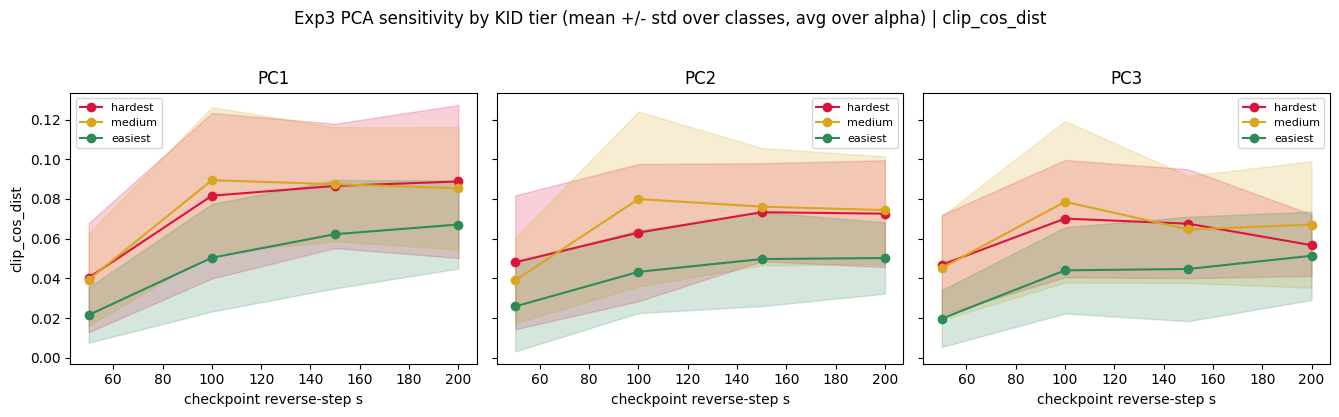

Saved ../results/exp3_pca_perturbation/tier_sensitivity_vs_checkpoint_dino_cos_dist.png


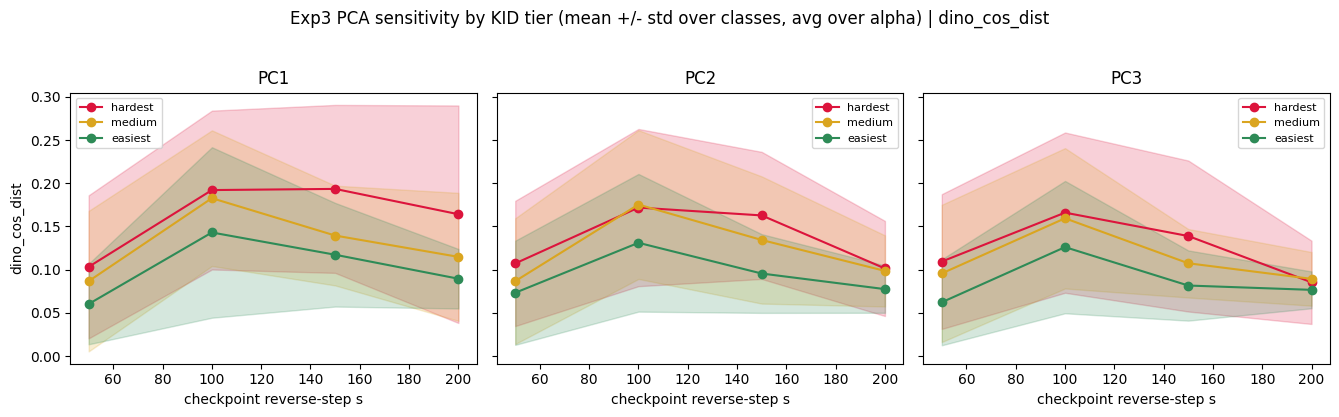

Saved ../results/exp3_pca_perturbation/tier_sensitivity_vs_checkpoint_lpips.png


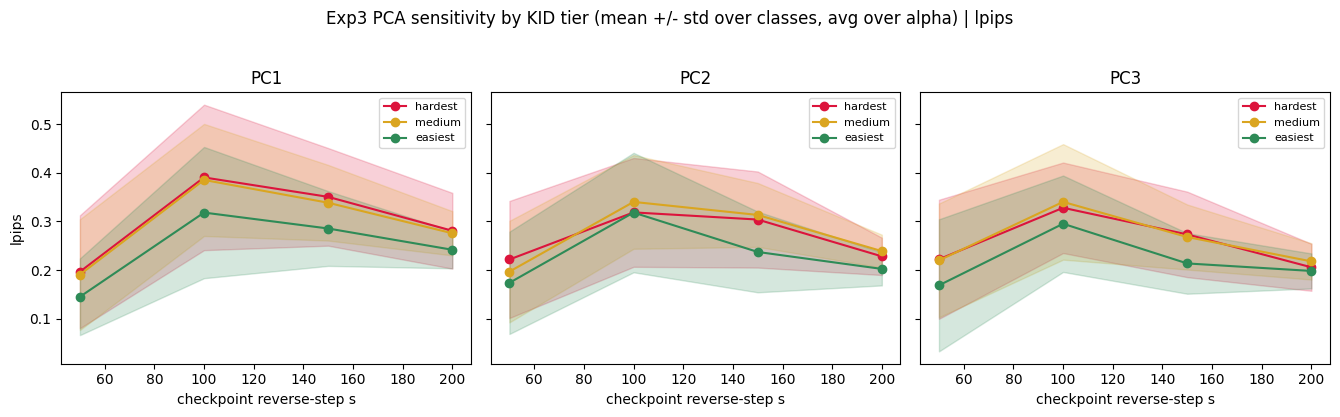

Saved ../results/exp3_pca_perturbation/tier_sensitivity_vs_checkpoint_latent_mse.png


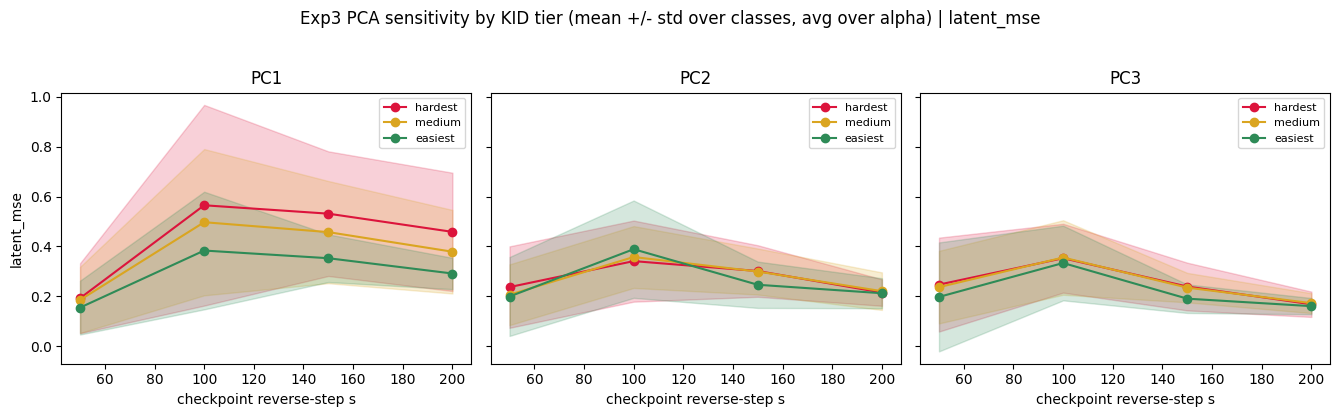

In [9]:
metric_keys = ["clip_cos_dist", "dino_cos_dist", "lpips", "latent_mse"]


def get_metric(class_label, s, c, alpha, key):
    k = f"s{s}_pc{c + 1}_a{alpha:+.1f}"
    return all_metrics[class_label]["exp3"][k][key]


def tier_mean_std(cls_list, s, c, alpha, key):
    vals = np.array([get_metric(cl, s, c, alpha, key) for cl in cls_list if cl in all_metrics])
    if len(vals) == 0:
        return np.nan, np.nan
    return float(vals.mean()), float(vals.std(ddof=0))


# Sensitivity vs checkpoint by tier (avg over alphas; mean±std across classes)
for key in metric_keys:
    fig, axes = plt.subplots(1, len(pca_components), figsize=(4.5 * len(pca_components), 4), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, c in zip(axes, pca_components):
        for tier_name, cls_list in tiers.items():
            means, stds = [], []
            for s in checkpoint_steps:
                per_class = []
                for cl in cls_list:
                    if cl not in all_metrics:
                        continue
                    per_class.append(np.mean([get_metric(cl, s, c, a, key) for a in alphas]))
                per_class = np.array(per_class)
                means.append(per_class.mean() if len(per_class) else np.nan)
                stds.append(per_class.std(ddof=0) if len(per_class) else np.nan)
            means, stds = np.array(means), np.array(stds)
            ax.plot(list(checkpoint_steps), means, marker="o", color=tier_colors[tier_name], label=tier_name)
            ax.fill_between(
                list(checkpoint_steps), means - stds, means + stds,
                color=tier_colors[tier_name], alpha=0.2,
            )
        ax.set_xlabel("checkpoint reverse-step s")
        ax.set_title(f"PC{c + 1}")
        ax.legend(fontsize=8)
    axes[0].set_ylabel(key)
    fig.suptitle(
        f"Exp3 PCA sensitivity by KID tier (mean +/- std over classes, avg over alpha) | {key}",
        y=1.03,
    )
    plt.tight_layout()
    fig_path = RESULTS_DIR / f"tier_sensitivity_vs_checkpoint_{key}.png"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved {fig_path}")
    plt.show()


Saved ../results/exp3_pca_perturbation/tier_heatmaps_clip_cos_dist.png


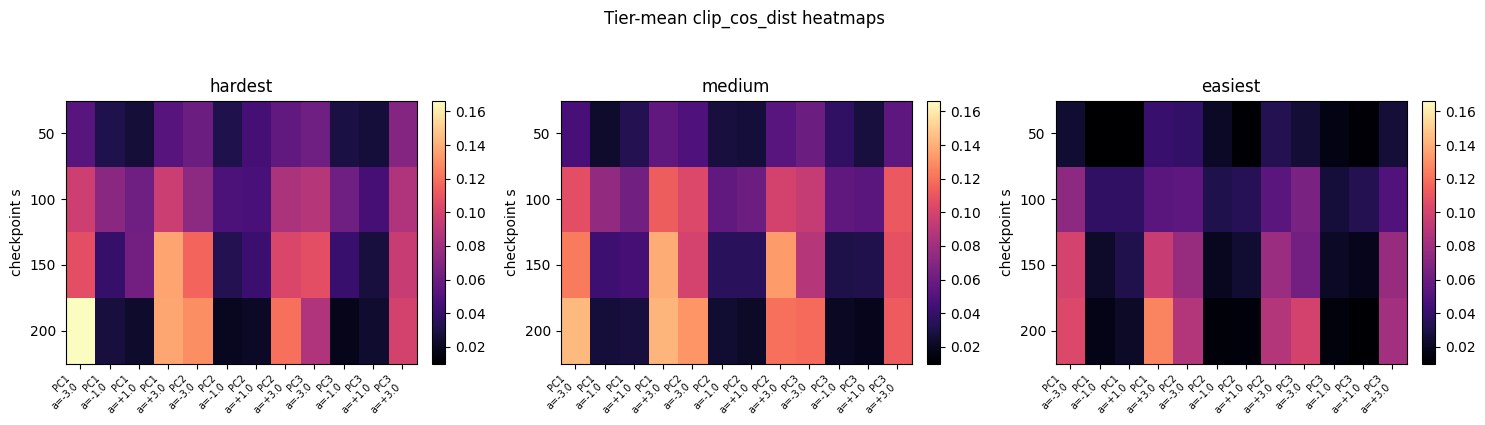

Saved ../results/exp3_pca_perturbation/tier_heatmaps_dino_cos_dist.png


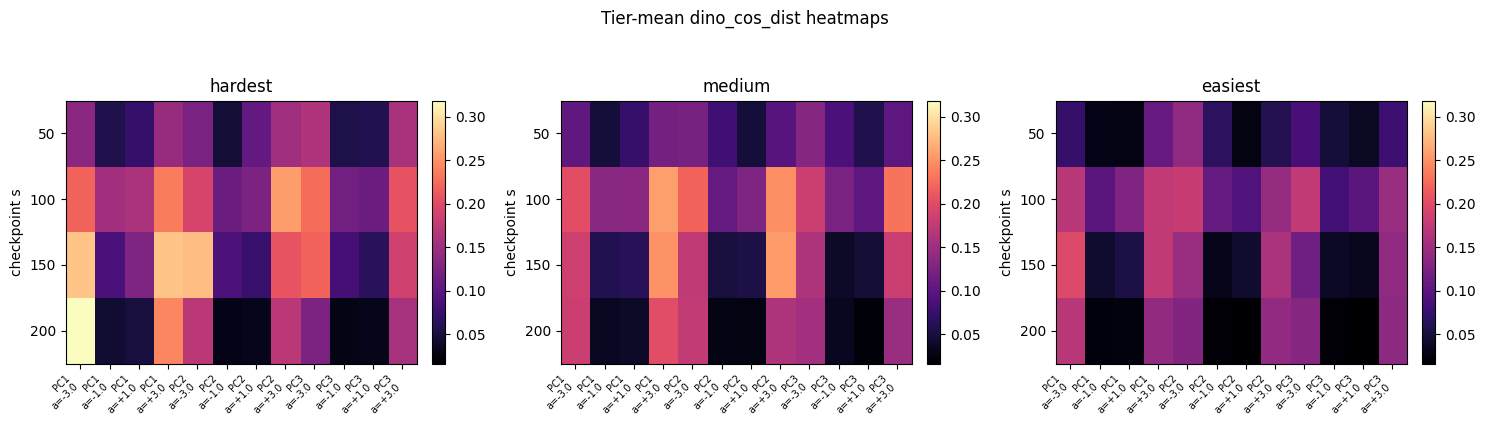

Saved ../results/exp3_pca_perturbation/tier_heatmaps_lpips.png


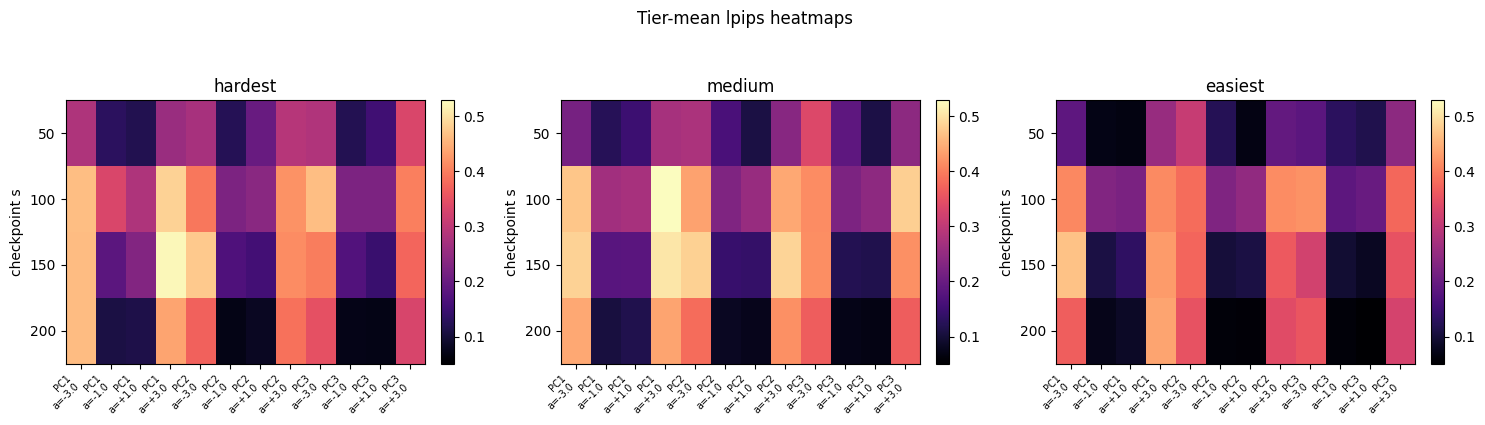

Saved ../results/exp3_pca_perturbation/tier_heatmaps_latent_mse.png


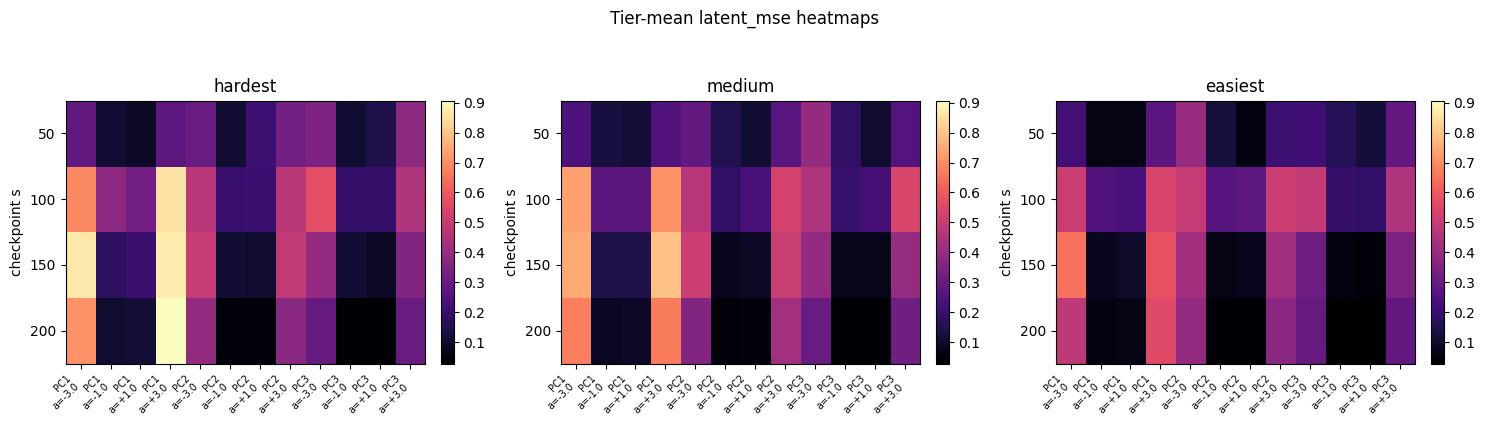

In [10]:
# Heatmap of tier-mean sensitivity: rows=checkpoint, cols=(PC x alpha), one panel per tier
combo_labels = [f"PC{c + 1}\na={a:+.1f}" for c in pca_components for a in alphas]

for key in metric_keys:
    fig, axes = plt.subplots(1, 3, figsize=(5 * 3, 4))
    mats = []
    for tier_name, cls_list in tiers.items():
        mat = np.array(
            [
                [
                    tier_mean_std(cls_list, s, c, a, key)[0]
                    for c in pca_components
                    for a in alphas
                ]
                for s in checkpoint_steps
            ]
        )
        mats.append(mat)
    vmin = np.nanmin([m.min() for m in mats])
    vmax = np.nanmax([m.max() for m in mats])
    for ax, (tier_name, _), mat in zip(axes, tiers.items(), mats):
        im = ax.imshow(mat, aspect="auto", cmap="magma", vmin=vmin, vmax=vmax)
        ax.set_xticks(range(len(combo_labels)))
        ax.set_xticklabels(combo_labels, fontsize=7, rotation=45, ha="right")
        ax.set_yticks(range(len(checkpoint_steps)))
        ax.set_yticklabels([str(s) for s in checkpoint_steps])
        ax.set_ylabel("checkpoint s")
        ax.set_title(tier_name)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(f"Tier-mean {key} heatmaps", y=1.05)
    plt.tight_layout()
    fig_path = RESULTS_DIR / f"tier_heatmaps_{key}.png"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved {fig_path}")
    plt.show()


/tmp/ipykernel_3255910/3881491809.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=True)
/tmp/ipykernel_3255910/3881491809.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=True)
/tmp/ipykernel_3255910/3881491809.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=True)
/tmp/ipykernel_3255910/3881491809.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since M

Saved ../results/exp3_pca_perturbation/tier_boxplots.png


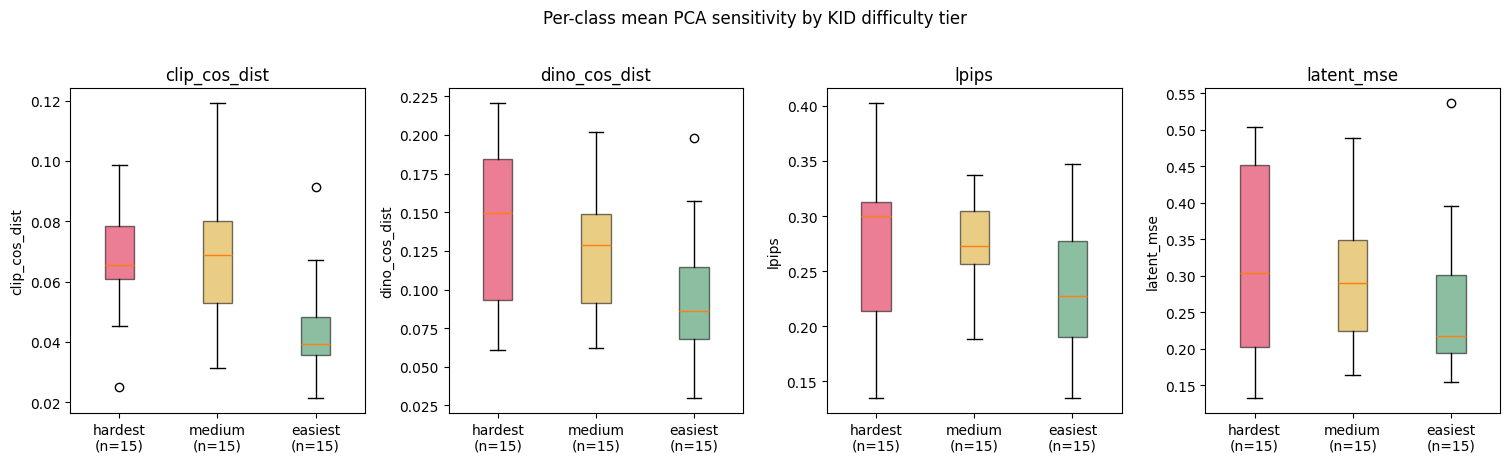

In [11]:
# Boxplot: per-class mean sensitivity (avg over s, PC, alpha) colored by tier
fig, axes = plt.subplots(1, len(metric_keys), figsize=(3.8 * len(metric_keys), 4.5))
axes = np.atleast_1d(axes)

for ax, key in zip(axes, metric_keys):
    data, labels, colors = [], [], []
    for tier_name, cls_list in tiers.items():
        vals = []
        for cl in cls_list:
            if cl not in all_metrics:
                continue
            vals.append(
                np.mean(
                    [
                        get_metric(cl, s, c, a, key)
                        for s in checkpoint_steps
                        for c in pca_components
                        for a in alphas
                    ]
                )
            )
        data.append(vals)
        labels.append(f"{tier_name}\n(n={len(vals)})")
        colors.append(tier_colors[tier_name])
    bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=True)
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.55)
    ax.set_ylabel(key)
    ax.set_title(key)
fig.suptitle("Per-class mean PCA sensitivity by KID difficulty tier", y=1.02)
plt.tight_layout()
fig_path = RESULTS_DIR / "tier_boxplots.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved {fig_path}")
plt.show()


# 9. Spotlight class visuals

Metrics for every class are already in `metrics_pca_perturbation.json` (all checkpoints). This section only **renders PNGs** at `spotlight_show_steps` (default s=100, 150) for the three spotlight classes — a short denoise pass, **not** a full experiment re-run.


In [ ]:
from IPython.display import display

# Render PNGs at s=100/150 if missing (uses cached traj + PCA ensemble only)
for tier_name, cl in spotlight_classes.items():
    save_spotlight_visuals(cl)

for tier_name, cl in spotlight_classes.items():
    samples_dir = RESULTS_DIR / f"class_{cl:04d}"
    print(
        f"\n=== Spotlight: {tier_name} | class {cl} ({class_names.get(cl, '?')}) "
        f"| KID={kid_per_class[cl]['kid']:.4f} | s={list(spotlight_show_steps)} ==="
    )
    paths = []
    for s in spotlight_show_steps:
        paths.extend(sorted(samples_dir.glob(f"grid_s{s}_pc*.png")))
        paths.extend(sorted(samples_dir.glob(f"diffmap_s{s}_pc*.png")))
    for path in paths:
        print(path)
        display(Image.open(path))
